In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re
import nltk
from nltk.stem.porter import PorterStemmer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

In [22]:
file_path = 'data/steam_games.csv'
nltk.download('stopwords')
nltk.download('punkt_tab')
stop_words = set(stopwords.words('english'))
#print(f"stopwords {list(stop_words)[:100]}")

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/felipecarpes/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/felipecarpes/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [23]:
def read_dataset(file_path):

    if not os.path.exists(file_path):
        print("ERRO: Arquivo de dados não encontrado!")
        return None

    df_complete = pd.read_csv(file_path,nrows=10000)
    
    return df_complete

In [24]:
def clean_text(text):
    porter = PorterStemmer()
    text = str(text)
    text = re.sub(r'<.*?>', ' ', text)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = text.lower()
    tokens = word_tokenize(text)
    tokens_clean = [word for word in tokens if word not in stop_words]
    tokens_stemmed=[porter.stem(word) for word in tokens_clean]
    return " ".join(tokens_stemmed)

In [25]:
df_bruto = read_dataset(file_path)

if df_bruto is not None:

    # Limpando o arquivo, selecionando colunas que podem ser utilizadas
    important = [
        'appid', 'name', 'genres', 'description', 'short_description'
    ]
    df = df_bruto[important].copy()
    display(df.head())

,appid,name,genres,description,short_description
0,10,Counter-Strike,Action,Play the world's number 1 online action game. ...,Play the world's number 1 online action game. ...
1,20,Team Fortress Classic,Action,One of the most popular online action games of...,One of the most popular online action games of...
2,30,Day of Defeat,Action,Enlist in an intense brand of Axis vs. Allied ...,Enlist in an intense brand of Axis vs. Allied ...
3,40,Deathmatch Classic,Action,Enjoy fast-paced multiplayer gaming with Death...,Enjoy fast-paced multiplayer gaming with Death...
4,50,Half-Life: Opposing Force,Action,Return to the Black Mesa Research Facility as ...,Return to the Black Mesa Research Facility as ...


In [26]:
game_descriptions_clean = df['description'].apply(clean_text)
#print(game_descriptions_clean.iloc[9])

In [27]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(max_df=0.6,min_df=10)
tfidf_matrix = vectorizer.fit_transform(game_descriptions_clean)
print(f"Formato da matriz: {tfidf_matrix.shape}")

Formato da matriz: (10000, 7009)


In [28]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import Normalizer
from sklearn.pipeline import make_pipeline

#teste de vizualizacao
reuzindo_para = 1000

# ler o artigo de SVD pra conferir essa seed
seed = 42 

#svd = TruncatedSVD(n_components = reuzindo_para, random_state = seed)
lsa_pipeline = make_pipeline(TruncatedSVD(n_components=1000, random_state=42), 
                              Normalizer(copy=False))
lsa=lsa_pipeline[0]
# Aplica tudo de uma vez na sua matriz TF-IDF
final_matrix = lsa_pipeline.fit_transform(tfidf_matrix)
#final_matrix = svd.fit_transform(tfidf_matrix)

print(f"original: {tfidf_matrix.shape}")
print(f"reduzido: {final_matrix.shape}")

original: (10000, 7009)
reduzido: (10000, 1000)


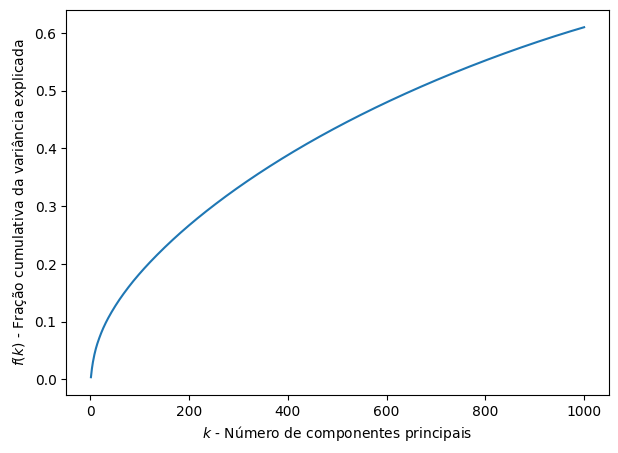

In [29]:
fig = plt.figure(figsize=(7, 5))
plt.plot([i for i in range(1, lsa.n_components + 1)], np.cumsum(lsa.explained_variance_ratio_))
plt.xlabel(r'$k$ - Número de componentes principais')
plt.ylabel(r'$f(k)$ - Fração cumulativa da variância explicada');

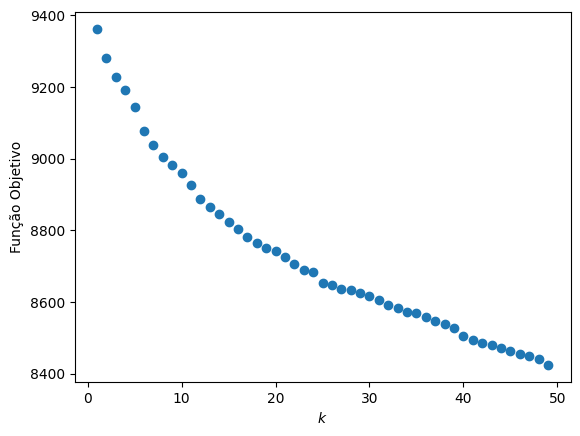

In [32]:
from sklearn.cluster import KMeans
from sklearn import cluster, datasets
inertia = []

for i in range(1, 50):
  km = cluster.KMeans(n_clusters = i,random_state=42)
  km.fit(final_matrix)
  inertia.append(km.inertia_)

plt.scatter(range(1, 50), inertia)
_ = plt.ylabel("Função Objetivo")
_ = plt.xlabel(r"$k$")